Symbolic convolution:
(1 - cos(t))⋅θ(t)


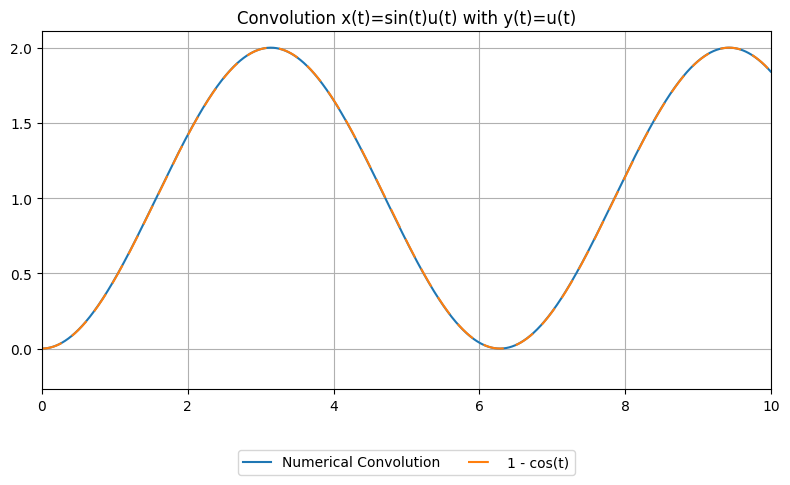

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import sympy as sp

# -------------------------
# SYMBOLIC CONVOLUTION
# -------------------------
t, tau = sp.symbols('t tau', real=True)

x_sym = sp.sin(tau) * sp.Heaviside(tau)
y_sym = sp.Heaviside(t - tau)

conv_sym = sp.integrate(x_sym * y_sym, (tau, -sp.oo, sp.oo))
conv_sym_simplified = sp.simplify(conv_sym)

print("Symbolic convolution:")
sp.pprint(conv_sym_simplified)

# -------------------------
# NUMERICAL CONVOLUTION
# -------------------------
t_num = np.linspace(0,10,2000)
dt = t_num[1]-t_num[0]

x = np.sin(t_num)
y = np.ones_like(t_num)

conv = signal.convolve(x, y, mode='full') * dt

t_conv = np.linspace(0, 2*t_num[-1], len(conv))

# theoretical result
theory = 1 - np.cos(t_num)

# -------------------------
# PLOT
# -------------------------
plt.figure(figsize=(8,5))

plt.plot(t_conv, conv, label="Numerical Convolution")
plt.plot(t_num, theory, '--', dashes=(10,6), label="1 - cos(t)")

plt.xlim(0,10)
plt.grid()
plt.title("Convolution x(t)=sin(t)u(t) with y(t)=u(t)")

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.tight_layout()
plt.show()